In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%reload_ext autoreload

In [ ]:
from utils import walk_naturally_sorted
from pathlib import Path
from report import parse_single_report
from collections import defaultdict

def load_single_report(experiment_folder): 
    grouped_results = defaultdict(list)
    for root, dirs, files in walk_naturally_sorted(experiment_folder):  
        for file in files: 
            if file.endswith("report.txt"):
                file_path = Path(root) / file
                try: 
                    results = parse_single_report(file_path)
                    group_value = results["n_agents"]

                    grouped_results[group_value].append(results)

                except Exception as e:
                    print(f"Error parsing {file_path}: {str(e)}")

    return grouped_results


experiment_folders = [
    "experiments/rule based/experiment_normal-case_2026-01-05_19-30-43",
    # "experiments/rule based/experiment_limited_2026-01-05_19-30-55",
    "experiment_test93_2026-02-08_13-14-34",
    # "experiments/rule based/experiment_toggle_2026-01-05_19-31-09",
    # "experiments/rule based/experiment_random_2026-01-05_19-31-26",
    # "experiments/rule based/experiment_adaptive-freq_2026-01-05_19-31-58",
    # "experiments/rule based/experiment_adaptive-limit_2026-01-05_19-31-41",

]
s_results = dict()
for experiment_folder in experiment_folders:
    experiment_title = experiment_folder.split("_")[1]
    s_results[experiment_title] = load_single_report(experiment_folder)


In [ ]:
for n in range (10, 101, 10): 
    print(f"config n = {n}")

    for alg, res in s_results.items(): 
        print(f"Results for {alg}")
        i = 0
        for stats in res[n]:
            i += 1
            # if float(stats["max_assistants"]) >= stats["assistant_limmt"]: 
            print("((", stats["max_assistants"], "/", stats["assistant_limmt"], "))", end="\t")
            if i % 10 == 0:
                print("|||||||", end="\t")
        print()

### Single Algorithm Results

In [ ]:
from report import load_results
from visualizations import plot_single_result

def produce_plots(experiment_folder, metric):
    grouping_field = "k"
    x_field = "n_agents"
    results = load_results(experiment_folder, grouping_field)

    print(results.keys())
    for i in range(9):
        plot_single_result(results, grouping_field, (i + 1) / 10, x_field=x_field, metric=metric, comparison_metric=None, secondary_metric=None)

    grouping_field = "n_agents"
    x_field = "k"
    results = load_results(experiment_folder, grouping_field)

    
    for i in range(9):
        plot_single_result(results, grouping_field, (i + 1) * 10, x_field=x_field, metric=metric, comparison_metric=None, secondary_metric=None)


In [ ]:
produce_plots(experiment_folder="experiment_normal-case_2025-12-25_20-56-12", metric="avg_max_comm")

### One-on-One comparison

In [423]:
def compare_results(result1, result2, metrics): 
    for metric in metrics: 
        print(f"Results for {metric}")

        for n in range (10, 101, 10): 
            print(f"config n = {n}")
            print("result 1")
            for stats in result1[n]:
                print(stats[metric], end="\t")
            print()
            print("result 2")
            for stats in result2[n]:
                print(stats[metric], end="\t")
            print()

In [424]:
from report import load_results

result1 = load_results("experiments/rule based/experiment_adaptive-freq_2026-05-04_17-43-24", "n_agents")
result2 = load_results("experiments/rule based/experiment_normal-case_2026-01-05_19-30-43", "n_agents")

max_dist_experiment_adaptive-freq_2026-05-04_17-43-24_std_dev_report.txt not found.
avg_dist_experiment_adaptive-freq_2026-05-04_17-43-24_std_dev_report.txt not found.
total_dist_experiment_adaptive-freq_2026-05-04_17-43-24_std_dev_report.txt not found.
max_comm_experiment_adaptive-freq_2026-05-04_17-43-24_std_dev_report.txt not found.
max_dist_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
avg_dist_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
total_dist_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
max_comm_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.


In [425]:
compare_results(result1, result2, ["avg_max_dist"])

Results for avg_max_dist
config n = 10
result 1
131.61404768081056	170.46964944315624	186.53926609506496	222.11123549376322	219.4909934697862	204.77393747070602	230.2826578855589	251.8349156460659	215.53545969527258	
result 2
133.02887725393654	172.4173133696834	192.7925768466098	223.08756820197414	221.0766885412492	200.39700899667696	230.2826578855589	251.8349156460659	215.53545969527258	
config n = 20
result 1
191.9393370227181	228.50169591058776	251.14989139869962	277.0428945931346	275.91029131055836	283.5071053953442	295.90990157180556	279.6929569318279	272.36026053180984	
result 2
192.24381124179214	225.66584178795634	241.97294945629943	277.09743726035333	267.1375045724564	285.2079365952833	302.7651323335777	281.4929569318279	274.95117182846457	
config n = 30
result 1
248.43035760371836	280.6376422467116	297.2731199414346	283.80461184302123	319.58985015355773	307.98273261049343	324.10194174875875	308.9742463337974	278.7902268311611	
result 2
248.43035760371836	280.93940533941424	2

### Multiple Algorithm Comparison

In [3]:
experiment_folders = [
    # correct comm range
    "experiments/rule based/experiment_normal-case_2026-01-05_19-30-43",
    "experiments/rule based/experiment_limited_2026-01-05_19-30-55",
    "experiments/rule based/experiment_toggle_2026-01-05_19-31-09",
    "experiments/rule based/experiment_random_2026-01-05_19-31-26",

    # "experiments/rule based/experiment_adaptive-freq_old_2026-05-05_03-41-07",
    "experiments/rule based/experiment_adaptive-freq_2026-05-07_00-11-56",
    "experiments/rule based/experiment_adaptive-freq-paper_2026-05-07_10-54-14",
    
    "experiments/rule based/experiment_adaptive-limit_2026-01-05_19-31-41",

    "experiments/rule based/experiment_no-assistant_2026-01-05_17-28-39", 
    "experiments/rule based/experiment_base-case_2026-01-06_11-00-24",

    # # specialized 
    "experiments/ai-based experiments/specialized/experiment_test31_2026-01-19_21-41-35", # DL
    "experiments/ai-based experiments/specialized/experiment_test42_2026-01-18_22-43-23", # SL
    "experiments/ai-based experiments/specialized/experiment_test44_2026-01-19_11-29-06", # SH
    "experiments/ai-based experiments/specialized/experiment_test45_2026-01-20_12-28-00", # DH

    # # domain randomization
    "experiments/ai-based experiments/domain randomization/experiment_test50_2026-01-29_16-32-29", # general
    "experiments/ai-based experiments/domain randomization/experiment_test51_2026-01-20_20-45-25", # SL 
    "experiments/ai-based experiments/domain randomization/experiment_test54_2026-01-21_11-08-19", # DL
    "experiments/ai-based experiments/domain randomization/experiment_test52_2026-01-20_21-53-11", # SH
    "experiments/ai-based experiments/domain randomization/experiment_test55_2026-01-22_15-09-31", # DH

    # # curriculum learning + specialized
    "experiments/ai-based experiments/curriculum learning/experiment_test61_2026-01-22_16-01-50",
    "experiments/ai-based experiments/curriculum learning/experiment_test62_2026-01-22_16-47-19", 
    "experiments/ai-based experiments/curriculum learning/experiment_test63_2026-01-23_11-35-04", 

    # # curriculum learning + domain randomization
    "experiments/ai-based experiments/curriculum learning/experiment_test70_2026-01-27_13-29-25", 
    "experiments/ai-based experiments/curriculum learning/experiment_test71_2026-01-27_13-29-41", 
    "experiments/ai-based experiments/curriculum learning/experiment_test72_2026-01-27_13-30-00", 
    "experiments/ai-based experiments/curriculum learning/experiment_test73_2026-01-27_13-30-14", 

    # ctde

    # tsp benchmark
    # n = 42
    # "tsp/Dantzig/experiment_no_assistant_bench_2026-04-14_14-07-46",
    # "tsp/Dantzig/experiment_normal_case_bench_2026-04-14_14-21-39",
    # "tsp/Dantzig/experiment_rand_bench_2026-04-14_16-26-54",
    # "tsp/Dantzig/experiment_specialized_DL_bench_2026-04-14_15-09-51",
    # "tsp/Dantzig/experiment_CLDR3_bench_2026-04-14_15-42-46",
    # "tsp/Dantzig/experiment_CLSSL_bench_2026-04-14_15-42-07",

    # n = 5
    # "tsp/five/experiment_no_assistant_bench_2026-04-14_23-30-53",
    # "tsp/five/experiment_normal_case_bench_2026-04-14_23-30-36",
    # "tsp/five/experiment_rand_bench_2026-04-14_23-31-19", 
    # "tsp/five/experiment_specialized_DL_bench_2026-04-14_23-30-20", 
    # "tsp/five/experiment_CLDR3_bench_2026-04-14_23-29-43", 
    # "tsp/five/experiment_CLSSL_bench_2026-04-14_23-30-05", 

    # # n = 26
    # "tsp/FRI26/experiment_no_assistant_bench_2026-04-14_22-27-08", 
    # "tsp/FRI26/experiment_normal_case_bench_2026-04-14_22-26-14", 
    # "tsp/FRI26/experiment_rand_bench_2026-04-14_22-28-17",
    # "tsp/FRI26/experiment_specialized_DL_bench_2026-04-14_22-25-08", 
    # "tsp/FRI26/experiment_CLDR3_bench_2026-04-14_22-24-09", 
    # "tsp/FRI26/experiment_CLSSL_bench_2026-04-14_22-24-38", 

    # # n = 17
    # "tsp/GR17/experiment_no_assistants_bench_2026-04-14_21-01-59", 
    # "tsp/GR17/experiment_normal_case_bench_2026-04-14_21-04-15", 
    # "tsp/GR17/experiment_rand_bench_2026-04-14_21-02-13", 
    # "tsp/GR17/experiment_specialized_DL_bench_2026-04-14_21-04-49",
    # "tsp/GR17/experiment_CLDR3_bench_2026-04-14_22-13-15", 
    # "tsp/GR17/experiment_CLSSL_bench_2026-04-14_22-12-37", 

    # # n = 15
    # "tsp/P01/experiment_no_assistants_bench_2026-04-14_16-48-05",
    # "tsp/P01/experiment_normal_case_bench_2026-04-14_16-48-52", 
    # "tsp/P01/experiment_rand_bench_2026-04-14_17-27-55",
    # "tsp/P01/experiment_specialized_DL_bench_2026-04-14_17-43-17",
    # "tsp/P01/experiment_CLDR3_bench_2026-04-14_17-29-08", 
    # "tsp/P01/experiment_CLSSL_bench_2026-04-14_17-29-26",

]

In [25]:
names = {
    "normal-case" : "AID",
    # "no-assistant" : "No Assistants",
    # "toggle" : "AID-Toggle",
    # "limited" : "AID-Limit",
    "random" : "AID-Rand",

    # "base-case" : "Full Knowledge", 

    # "adaptive-freq" : "AID-Freq",
    # "adaptive-freq-paper" : "AID-Freq",
    # "adaptive-limit" : "AID-Adaptive",

    # "CLDR3": "CL-DR Stage III", 
    # "CLSSL": "CL-S SL", 
    # "specialized": "Specialized-DL", 
    # "no": "No Assistants", 
    # "normal": "AID", 
    # "rand": "AID-Rand", 
    # "benchmark": "Benchmark",
###################################################################
    # specialized models
    "test31": "Specialized-DL", # 50, 5
    # "test44": "Specialized-SH", # 30, 15 # ?maybe try to train only for 200 ep? 
    "test42": "Specialized-SL", # 30, 6
    # "test45": "Specialized-DH", # 60, 30

    # domain randomization models
    # "test50": "Domain-Rand-G",
    # "test54": "Domain-Rand-DL",
    # "test55": "Domain-Rand-DH",
    # "test51": "Domain-Rand-SL",
    # "test52": "Domain-Rand-SH",
    # "test53": "dr sparse high 1k ep",

    # curriculum learning models + specialized
    "test61": "CL-S SL",
    # "test62": "CL-S SH",
    # "test63": "CL-S DH",

    # curriculum learning + domain randomization
    # "test70": "CL-DR stage I",
    # "test71": "CL-DR stage II",
    # "test72": "CL-DR stage III",
    # "test73": "CL-DR stage IV",


}

#### Group By N 

In [5]:
from report import load_multiple_results

grouping_field = "n_agents"
results_by_agents = load_multiple_results(experiment_folders, grouping_field) 

max_dist_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
avg_dist_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
total_dist_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
max_comm_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
max_dist_experiment_limited_2026-01-05_19-30-55_std_dev_report.txt not found.
avg_dist_experiment_limited_2026-01-05_19-30-55_std_dev_report.txt not found.
total_dist_experiment_limited_2026-01-05_19-30-55_std_dev_report.txt not found.
max_comm_experiment_limited_2026-01-05_19-30-55_std_dev_report.txt not found.
max_dist_experiment_toggle_2026-01-05_19-31-09_std_dev_report.txt not found.
avg_dist_experiment_toggle_2026-01-05_19-31-09_std_dev_report.txt not found.
total_dist_experiment_toggle_2026-01-05_19-31-09_std_dev_report.txt not found.
max_comm_experiment_toggle_2026-01-05_19-31-09_std_dev_report.txt not found.
max_dist_experiment_random_2026-01-05_19-31-26

In [24]:
from visualizations import plot_comparative_algorithms

grouping_field = "n_agents"

# plot_comparative_algorithms(names, results_by_agents, grouping_field, 15, "k", "avg_max_dist", bench_value=291)
# plot_comparative_algorithms(names, results_by_agents, grouping_field, 15, "k", "avg_total_dist", bench_value=291)

for i in range(10):
    plot_comparative_algorithms(names, results_by_agents, grouping_field, (i + 1) * 10, "k", "avg_max_dist")
# plot_comparative_algorithms(names, results_by_agents, grouping_field, 30, "k", "avg_max_dist")
# plot_comparative_algorithms(names, results_by_agents, grouping_field, 20, "k", "avg_max_dist")

# for i in range(10):
#     plot_comparative_algorithms(names, results_by_agents, grouping_field, (i + 1) * 10, "k", "avg_total_dist")
# plot_comparative_algorithms(names, results_by_agents, grouping_field, 20, "k", "avg_total_dist")
# plot_comparative_algorithms(names, results_by_agents, grouping_field, 60, "k", "avg_total_dist")

# for i in range(10):
#     plot_comparative_algorithms(names, results_by_agents, grouping_field, (i + 1) * 10, "k", "avg_max_comm")
# plot_comparative_algorithms(names, results_by_agents, grouping_field, 20, "k", "avg_max_comm")
# plot_comparative_algorithms(names, results_by_agents, grouping_field, 60, "k", "avg_max_comm")


In [137]:
print(results_by_agents["CLDR3"])

KeyError: 'CL-DR stage III'

In [12]:
from visualizations import plot_graph_single_configuration

plot_graph_single_configuration(names, results_by_agents, 
                              comparison_value="60", x_value= "0.5",
                              metric= 'avg_max_dist')

#### Group By K

In [100]:
from report import load_multiple_results

grouping_field = "k"
results = load_multiple_results(experiment_folders, grouping_field) 


max_dist_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
avg_dist_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
total_dist_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
max_comm_experiment_normal-case_2026-01-05_19-30-43_std_dev_report.txt not found.
max_dist_experiment_limited_2026-01-05_19-30-55_std_dev_report.txt not found.
avg_dist_experiment_limited_2026-01-05_19-30-55_std_dev_report.txt not found.
total_dist_experiment_limited_2026-01-05_19-30-55_std_dev_report.txt not found.
max_comm_experiment_limited_2026-01-05_19-30-55_std_dev_report.txt not found.
max_dist_experiment_toggle_2026-01-05_19-31-09_std_dev_report.txt not found.
avg_dist_experiment_toggle_2026-01-05_19-31-09_std_dev_report.txt not found.
total_dist_experiment_toggle_2026-01-05_19-31-09_std_dev_report.txt not found.
max_comm_experiment_toggle_2026-01-05_19-31-09_std_dev_report.txt not found.
max_dist_experiment_random_2026-01-05_19-31-26

In [101]:
from visualizations import plot_comparative_algorithms

grouping_field = "k"

# for i in range(10):
#     plot_comparative_algorithms(names, results, grouping_field, (i + 1) / 10, "n_agents", "avg_total_dist")
# plot_comparative_algorithms(names, results, grouping_field, 0.3, "n_agents", "avg_total_dist")
# plot_comparative_algorithms(names, results, grouping_field, 0.7, "n_agents", "avg_total_dist")

# plot_comparative_algorithms(names, results, grouping_field, 0.3, "n_agents", "avg_total_dist")
# for i in range(10):
#     plot_comparative_algorithms(names, results, grouping_field, (i + 1) / 10, "n_agents", "avg_max_dist")
plot_comparative_algorithms(names, results, grouping_field, 0.2, "n_agents", "avg_max_dist")
# plot_comparative_algorithms(names, results, grouping_field, 0.3, "n_agents", "avg_max_dist")

# for i in range(10):
#     plot_comparative_algorithms(names, results, grouping_field, (i + 1) / 10, "n_agents", "avg_max_comm")

# avg_assistants
# avg_max_dist/
# avg_avg_dist
# avg_total_dist
# avg_steps
# avg_max_comm

#### std calculations

In [40]:
from report import write_std_dev_report

metrics = ["max_dist", "avg_dist", "total_dist", "max_comm"]
for experiment_folder in experiment_folders:
    output_file = experiment_folder.split("/")[-1] + "_std_dev_report.txt"
    write_std_dev_report(experiment_folder, output_file, metrics)


Error parsing experiments\rule based\experiment_normal-case_2026-01-05_19-30-43\agent_10\k_1\avg_report.txt: 'total_dist'
Error parsing experiments\rule based\experiment_normal-case_2026-01-05_19-30-43\agent_10\k_2\avg_report.txt: 'total_dist'
Error parsing experiments\rule based\experiment_normal-case_2026-01-05_19-30-43\agent_10\k_3\avg_report.txt: 'total_dist'
Error parsing experiments\rule based\experiment_normal-case_2026-01-05_19-30-43\agent_10\k_4\avg_report.txt: 'total_dist'
Error parsing experiments\rule based\experiment_normal-case_2026-01-05_19-30-43\agent_10\k_5\avg_report.txt: 'total_dist'
Error parsing experiments\rule based\experiment_normal-case_2026-01-05_19-30-43\agent_10\k_6\avg_report.txt: 'total_dist'
Error parsing experiments\rule based\experiment_normal-case_2026-01-05_19-30-43\agent_10\k_7\avg_report.txt: 'total_dist'
Error parsing experiments\rule based\experiment_normal-case_2026-01-05_19-30-43\agent_10\k_8\avg_report.txt: 'total_dist'
Error parsing experiment

#### win table

In [26]:
# "normal-case", "limited", "toggle", "adaptive-limit", "adaptive-freq", "random", "no-assistant", 
# "test31", "test42", "test44", "test45",  
# "test61", "test62", "test63", 
# "test50", "test51", "test52", "test54", "test55", 
# "test70", "test71", "test72", "test73",
algorithms = ["test31", "test42", "test61"]

In [30]:
from report import compute_win_table


win_table = compute_win_table(results_by_agents, "avg_total_dist", algorithms)

defaultdict(<class 'int'>, {'Sparse + Low': 16, 'Sparse + High': 20, 'Dense + Low': 24, 'Dense + High': 30})


In [28]:
print(win_table)

defaultdict(<function compute_win_table.<locals>.<lambda> at 0x0000021303C06FC0>, {'Sparse + Low': defaultdict(<function compute_win_table.<locals>.<lambda>.<locals>.<lambda> at 0x0000021303C06E80>, {'test31': {'wins': 12, 'ties': 0, 'losses': 4}, 'test42': {'wins': 1, 'ties': 0, 'losses': 15}, 'test61': {'wins': 3, 'ties': 0, 'losses': 13}}), 'Sparse + High': defaultdict(<function compute_win_table.<locals>.<lambda>.<locals>.<lambda> at 0x0000021303C06480>, {'test61': {'wins': 8, 'ties': 0, 'losses': 12}, 'test31': {'wins': 9, 'ties': 0, 'losses': 11}, 'test42': {'wins': 3, 'ties': 0, 'losses': 17}}), 'Dense + Low': defaultdict(<function compute_win_table.<locals>.<lambda>.<locals>.<lambda> at 0x0000021303C06160>, {'test31': {'wins': 23, 'ties': 0, 'losses': 1}, 'test42': {'wins': 1, 'ties': 0, 'losses': 23}, 'test61': {'wins': 0, 'ties': 0, 'losses': 24}}), 'Dense + High': defaultdict(<function compute_win_table.<locals>.<lambda>.<locals>.<lambda> at 0x0000021303C06020>, {'test31': {

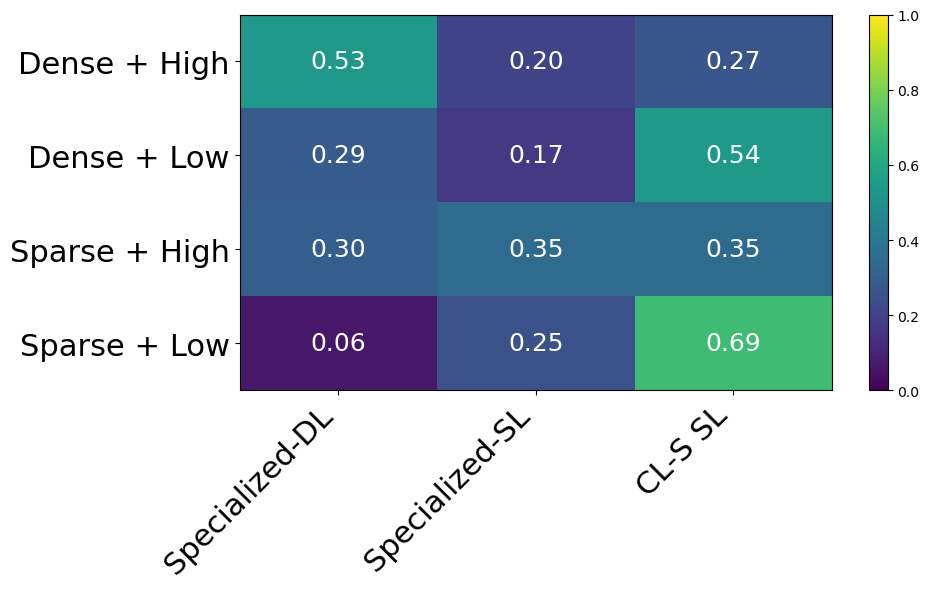

In [31]:
from visualizations import plot_win_table_heatmap

plot_win_table_heatmap(
    names,
    win_table,
    algorithms=algorithms,
    normalize="win_rate",
    title="Win Rate Heatmap - Rule-Based Algorithms"
)

#### Average stats comparison

In [ ]:
import numpy as np

def quick_improvement(values_a, values_b):
    """
    Quick calculation of average improvement.
    
    Parameters:
    values_a, values_b : lists or arrays of metric values
                         (assumes lower is better)
    
    Returns:
    Average improvement percentage
    """
    a = np.array(values_a)
    b = np.array(values_b)
    improvement = ((b - a) / b) * 100
    return np.mean(improvement)


def get_values_by_metric(results, alg, metric): 
    final_data = []
    for n in range(10, 101, 10): 
        for k in range(1, 10): 
            data = results[alg][n]
            sorted_data = [data[metric] for data in sorted(data, key=lambda x: x["k"])]
            final_data.extend(sorted_data)
    return final_data
    
# Example
specialized = get_values_by_metric(results_by_agents, "test61", "avg_max_dist")
aid = get_values_by_metric(results_by_agents, "no-assistant", "avg_max_dist")

# curriculum learning models + specialized
# "test61": "CL-S SL",
# "test62": "CL-S SH",
# "test63": "CL-S DH",
# curriculum learning + domain randomization
# "test70": "CL-DR stage I",
# "test71": "CL-DR stage II",
# "test72": "CL-DR stage III",
# "test73": "CL-DR stage IV",
# "test31": "Specialized-DL", # 50, 5
# "test44": "Specialized-SH", # 30, 15 # ?maybe try to train only for 200 ep? 
# "test42": "Specialized-SL", # 30, 6
# "test45": "Specialized-DH", # 60, 30
# domain randomization models
# "test50": "Domain-Rand-G",
# "test54": "Domain-Rand-DL",
# "test55": "Domain-Rand-DH",
# "test51": "Domain-Rand-SL",
# "test52": "Domain-Rand-SH",
# "test53": "dr sparse high 1k ep",

print(f"Average improvement: {quick_improvement(specialized, aid):.1f}%")

Average improvement: -1.2%
